# Aula 4 — Benchmark Textual entre Modelos

Este notebook compara **Kimi**, **Claude Opus** e **GPT-5.5** em tarefas textuais.

**Objetivo:** medir custo, tempo e qualidade das respostas para o mesmo prompt.

**Métricas:**
- Tokens de entrada e saída
- Tempo de resposta
- Custo estimado
- Qualidade da resposta (avaliação manual)

## 1. Instalação das dependências

Descomente e execute a linha abaixo caso ainda não tenha instalado.

In [ ]:
# !pip install openai anthropic python-dotenv pandas matplotlib

## 2. Configuração do ambiente

In [1]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Clientes das APIs
import openai
import anthropic

load_dotenv()

KIMI_API_KEY = os.getenv("KIMI_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# Inicialização dos clientes
kimi_client = openai.OpenAI(api_key=KIMI_API_KEY, base_url="https://api.moonshot.ai/v1")
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)


## 3. Tabela de preços

Atualize os valores conforme a tabela oficial de cada provider no momento da gravação da aula.

In [2]:
# Preços por 1M tokens (USD) — verificados em 2026-08-03.
# As chaves precisam bater com o campo "provider" retornado por cada call_*().
PRICES = {
    "kimi":        {"input":  3.00, "output": 15.00},  # kimi-k3 (Moonshot)
    "claude-opus": {"input":  5.00, "output": 25.00},  # claude-opus-5 (Anthropic)
    "gpt-5.5":     {"input":  5.00, "output": 30.00},  # gpt-5.5 (OpenAI), faixa <272K
}


## 4. Funções padronizadas de chamada

In [3]:
def call_kimi(system_prompt, user_prompt, model="kimi-k3"):
    start = time.time()
    response = kimi_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=1.0
    )
    elapsed = time.time() - start
    return {
        "provider": "kimi",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }

def call_claude(system_prompt, user_prompt, model="claude-opus-5"):
    start = time.time()
    # O claude-opus-5 não aceita temperature (400 invalid_request_error) e vem com
    # thinking ligado por padrão, que consome parte do max_tokens — por isso o
    # limite é mais folgado que os 4096 usados no opus-4-6.
    response = anthropic_client.messages.create(
        model=model,
        max_tokens=16000,
        system=system_prompt,
        messages=[{"role": "user", "content": user_prompt}]
    )
    elapsed = time.time() - start
    # Com thinking ligado, content[0] é um bloco 'thinking'; o texto vem depois.
    text = next(b.text for b in response.content if b.type == "text")
    return {
        "provider": "claude-opus",
        "model": model,
        "response": text,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_tokens": response.usage.input_tokens + response.usage.output_tokens,
        "time_seconds": elapsed
    }

def call_openai(system_prompt, user_prompt, model="gpt-5.5"):
    start = time.time()
    # O gpt-5.5 aceita apenas o temperature padrão (1). Enviar outro valor devolve
    # 400 unsupported_value, por isso o parâmetro é omitido aqui.
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    elapsed = time.time() - start
    return {
        "provider": "gpt-5.5",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }


## 5. Funções de cálculo de custo e execução do benchmark

In [4]:
def calculate_cost(provider, input_tokens, output_tokens):
    prices = PRICES.get(provider, {})
    input_cost = (input_tokens / 1_000_000) * prices.get("input", 0)
    output_cost = (output_tokens / 1_000_000) * prices.get("output", 0)
    return round(input_cost + output_cost, 6)

# Nome do provider por função de chamada — usado quando a call falha,
# para que a linha de erro use a mesma chave de PRICES/quality_scores.
CALLER_PROVIDERS = {
    "call_kimi": "kimi",
    "call_claude": "claude-opus",
    "call_openai": "gpt-5.5",
}

# Colunas métricas (sem o texto da resposta) — úteis para exibir tabelas e gráficos.
METRIC_COLUMNS = [
    "task", "provider", "model",
    "input_tokens", "output_tokens", "total_tokens",
    "time_seconds", "cost_usd",
]

def run_textual_benchmark(system_prompt, user_prompt, task_name="tarefa"):
    """
    Executa o mesmo prompt nos 4 modelos e retorna um DataFrame comparativo.
    O texto gerado fica na coluna "response" (última do DataFrame).
    """
    results = []
    callers = [call_kimi, call_claude, call_openai]

    for caller in callers:
        try:
            result = caller(system_prompt, user_prompt)
            result["cost_usd"] = calculate_cost(
                result["provider"],
                result["input_tokens"],
                result["output_tokens"]
            )
            result["task"] = task_name
            results.append(result)
        except Exception as e:
            results.append({
                "provider": CALLER_PROVIDERS.get(caller.__name__, caller.__name__),
                "model": "error",
                "response": f"[ERRO] {type(e).__name__}: {e}",
                "input_tokens": 0,
                "output_tokens": 0,
                "total_tokens": 0,
                "time_seconds": 0,
                "cost_usd": 0,
                "task": task_name
            })

    df = pd.DataFrame(results)
    # Mantém "response" no DataFrame — display_responses() depende dela.
    return df[METRIC_COLUMNS + ["response"]]

def metrics(df):
    """Versão só com métricas, para exibir a tabela sem o texto das respostas."""
    return df[METRIC_COLUMNS]

def display_responses(df):
    for _, row in df.iterrows():
        text = str(row["response"])
        print(f"\n{'='*60}")
        print(f"PROVIDER: {row['provider'].upper()} | MODEL: {row['model']}")
        print(f"TOKENS: {row['total_tokens']} | TIME: {row['time_seconds']:.2f}s | COST: ${row['cost_usd']:.6f}")
        print(f"{'='*60}")
        print(text[:800] + "..." if len(text) > 800 else text)
        print()

## 6. Benchmark 1 — Resumo de texto técnico

In [5]:
system_prompt = "Você é um especialista em tecnologia. Resuma o texto de forma clara e objetiva, mantendo os pontos técnicos principais."

texto_tecnico = """
Large Language Models (LLMs) são modelos de inteligência artificial baseados na arquitetura Transformer,
treinados com grandes quantidades de texto para prever a próxima palavra em uma sequência. Eles são capazes
de gerar texto, responder perguntas, resumir documentos, traduzir idiomas e auxiliar na programação.
Modelos como GPT-4, Claude, Gemini e Kimi utilizam técnicas como attention mechanisms, fine-tuning e
reinforcement learning from human feedback (RLHF) para melhorar a qualidade das respostas. A escolha de
um LLM para um projeto depende de fatores como custo por token, tamanho de contexto, latência,
multimodalidade e capacidade de seguir instruções complexas.
"""

user_prompt = f"Resuma o seguinte texto em no máximo 3 parágrafos:\n\n{texto_tecnico}"

df_resumo = run_textual_benchmark(system_prompt, user_prompt, task_name="resumo")
metrics(df_resumo)

,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,resumo,kimi,kimi-k3,328,472,800,17.751950,0.008064
1,resumo,claude-opus,claude-opus-5,342,385,727,8.563834,0.011335
2,resumo,gpt-5.5,gpt-5.5,186,133,319,3.368370,0.004920


In [6]:
display_responses(df_resumo)


PROVIDER: KIMI | MODEL: kimi-k3
TOKENS: 800 | TIME: 17.75s | COST: $0.008064
**Resumo**

Large Language Models (LLMs) são modelos de IA baseados na arquitetura Transformer, treinados em grandes volumes de texto com o objetivo de prever a próxima palavra de uma sequência. A partir desse princípio, são capazes de executar tarefas como geração de texto, resposta a perguntas, sumarização de documentos, tradução e auxílio em programação.

Modelos como GPT-4, Claude, Gemini e Kimi aprimoram a qualidade de suas respostas por meio de técnicas como *attention mechanisms*, *fine-tuning* e aprendizado por reforço com feedback humano (RLHF).

A escolha de um LLM para um projeto deve considerar critérios técnicos e operacionais, como custo por token, tamanho da janela de contexto, latência, suporte à multimodalidade e capacidade de seguir instruções complexas.


PROVIDER: CLAUDE-OPUS | MODEL: claude-opus-5
TOKENS: 727 | TIME: 8.56s | COST: $0.011335
**Resumo**

Large Language Models (LLMs) são mod

## 7. Benchmark 2 — Explicação de conceito

In [7]:
system_prompt = "Você é um professor de programação. Explique conceitos técnicos de forma simples, com exemplos práticos."

user_prompt = """Explique o que é uma API REST e por que ela é importante no desenvolvimento web.
Use no máximo 200 palavras e inclua um exemplo prático."""

df_conceito = run_textual_benchmark(system_prompt, user_prompt, task_name="explicacao_conceito")
metrics(df_conceito)

,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,explicacao_conceito,kimi,kimi-k3,163,670,833,18.933387,0.010539
1,explicacao_conceito,claude-opus,claude-opus-5,97,663,760,10.676311,0.017060
2,explicacao_conceito,gpt-5.5,gpt-5.5,62,306,368,7.140730,0.009490


In [8]:
display_responses(df_conceito)


PROVIDER: KIMI | MODEL: kimi-k3
TOKENS: 833 | TIME: 18.93s | COST: $0.010539
# API REST: O Que É e Por Que Importa

## O que é?

Uma **API REST** é uma forma padronizada de sistemas conversarem pela web usando o protocolo HTTP. Pense nela como um **garçom**: você (cliente) faz um pedido, ele leva à cozinha (servidor) e traz o prato pronto (resposta).

O REST usa os **verbos HTTP** para manipular recursos:
- `GET` → buscar dados
- `POST` → criar dados
- `PUT/PATCH` → atualizar dados
- `DELETE` → remover dados

## Por que é importante?

1. **Separação de responsabilidades**: o frontend (o que o usuário vê) fica independente do backend (a lógica e os dados).
2. **Reutilização**: uma única API pode atender site, aplicativo mobile e até outros sistemas.
3. **Padronização**: qualquer desenvolvedor entende como consumir uma API REST, facilitando integrações (ex: login com...


PROVIDER: CLAUDE-OPUS | MODEL: claude-opus-5
TOKENS: 760 | TIME: 10.68s | COST: $0.017060
## O que é uma API REST?



## 8. Benchmark 3 — Geração de ideias

In [9]:
system_prompt = "Você é um Product Manager experiente. Gere ideias criativas e viáveis para produtos digitais."

user_prompt = """Sugira 3 funcionalidades para um aplicativo de produtividade que use IA para ajudar
desenvolvedores a gerenciar tarefas. Para cada funcionalidade, dê um nome, descreva o problema que resolve
e explique como a IA seria usada."""

df_ideias = run_textual_benchmark(system_prompt, user_prompt, task_name="geracao_ideias")
metrics(df_ideias)

,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,geracao_ideias,kimi,kimi-k3,190,2542,2732,79.175363,0.03870
1,geracao_ideias,claude-opus,claude-opus-5,135,3311,3446,54.155583,0.08345
2,geracao_ideias,gpt-5.5,gpt-5.5,78,521,599,11.536009,0.01602


In [10]:
display_responses(df_ideias)


PROVIDER: KIMI | MODEL: kimi-k3
TOKENS: 2732 | TIME: 79.18s | COST: $0.038700
# 3 Funcionalidades de IA para Gestão de Tarefas de Devs

## 1. Quebra-Tarefas (Decomposição Inteligente)

**Problema que resolve:** Devs frequentemente recebem tarefas grandes e vagas ("implementar autenticação", "migrar para a nova API") que são difíceis de começar e impossíveis de estimar. Isso gera procrastinação e sprints furadas.

**Como a IA seria usada:** Ao criar uma tarefa, o usuário descreve o objetivo em linguagem natural. A IA analisa o contexto do repositório (via integração com GitHub/GitLab: estrutura de pastas, histórico de mudanças) e sugere uma divisão em subtarefas acionáveis e ordenadas, indicando quais arquivos ou módulos cada uma provavelmente afeta. O dev edita ou descarta sugestões, e o sistema aprende com esses ajustes ao longo do tempo.

## 2. Estimador Realista
...


PROVIDER: CLAUDE-OPUS | MODEL: claude-opus-5
TOKENS: 3446 | TIME: 54.16s | COST: $0.083450
## Premissa do produto



## 9. Consolidação dos resultados

In [11]:
df_all = pd.concat([df_resumo, df_conceito, df_ideias], ignore_index=True)
metrics(df_all)

,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd
0,resumo,kimi,kimi-k3,328,472,800,17.751950,0.008064
1,resumo,claude-opus,claude-opus-5,342,385,727,8.563834,0.011335
2,resumo,gpt-5.5,gpt-5.5,186,133,319,3.368370,0.004920
3,explicacao_conceito,kimi,kimi-k3,163,670,833,18.933387,0.010539
4,explicacao_conceito,claude-opus,claude-opus-5,97,663,760,10.676311,0.017060
5,explicacao_conceito,gpt-5.5,gpt-5.5,62,306,368,7.140730,0.009490
6,geracao_ideias,kimi,kimi-k3,190,2542,2732,79.175363,0.038700
7,geracao_ideias,claude-opus,claude-opus-5,135,3311,3446,54.155583,0.083450
8,geracao_ideias,gpt-5.5,gpt-5.5,78,521,599,11.536009,0.016020


## 10. Visualização comparativa

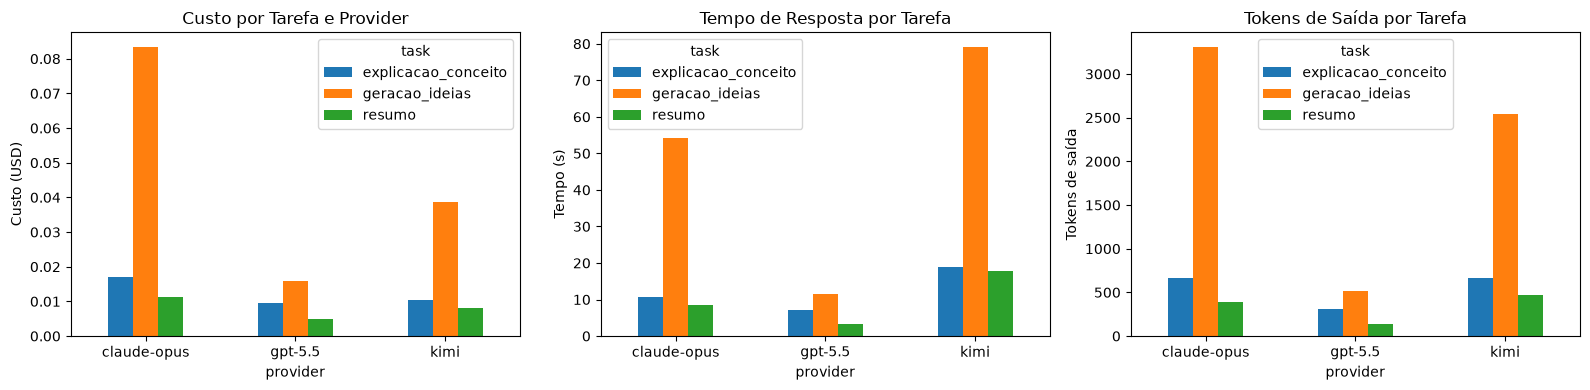

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Custo por tarefa
df_all.pivot(index="provider", columns="task", values="cost_usd").plot.bar(
    ax=axes[0], title="Custo por Tarefa e Provider", rot=0
)
axes[0].set_ylabel("Custo (USD)")

# Tempo por tarefa
df_all.pivot(index="provider", columns="task", values="time_seconds").plot.bar(
    ax=axes[1], title="Tempo de Resposta por Tarefa", rot=0
)
axes[1].set_ylabel("Tempo (s)")

# Tokens de saída por tarefa
df_all.pivot(index="provider", columns="task", values="output_tokens").plot.bar(
    ax=axes[2], title="Tokens de Saída por Tarefa", rot=0
)
axes[2].set_ylabel("Tokens de saída")

plt.tight_layout()
plt.show()

## 11. Avaliação de qualidade

Após analisar as respostas, atribua uma nota de 1 a 5 para cada provider em cada tarefa.

Critérios sugeridos:
- Clareza e organização
- Fidelidade ao pedido
- Profundidade técnica
- Concisão

In [13]:
# Exemplo de notas manuais (substitua pelas suas avaliações reais)
quality_scores = {
    ("kimi", "resumo"): 4,
    ("claude-opus", "resumo"): 5,
    ("gpt-5.5", "resumo"): 4,
    ("kimi", "explicacao_conceito"): 5,
    ("claude-opus", "explicacao_conceito"): 5,
    ("gpt-5.5", "explicacao_conceito"): 4,
    ("kimi", "geracao_ideias"): 4,
    ("claude-opus", "geracao_ideias"): 5,
    ("gpt-5.5", "geracao_ideias"): 4,
}

df_all["quality_score"] = df_all.apply(
    lambda row: quality_scores.get((row["provider"], row["task"]), 3), axis=1
)

# Custo-benefício: pontos de qualidade por dólar gasto
df_all["efficiency"] = df_all.apply(
    lambda row: round(row["quality_score"] / max(row["cost_usd"], 0.000001), 2), axis=1
)

df_all[["task", "provider", "cost_usd", "quality_score", "efficiency"]]

,task,provider,cost_usd,quality_score,efficiency
0,resumo,kimi,0.008064,4,496.03
1,resumo,claude-opus,0.011335,5,441.11
2,resumo,gpt-5.5,0.004920,4,813.01
3,explicacao_conceito,kimi,0.010539,5,474.43
4,explicacao_conceito,claude-opus,0.017060,5,293.08
5,explicacao_conceito,gpt-5.5,0.009490,4,421.50
6,geracao_ideias,kimi,0.038700,4,103.36
7,geracao_ideias,claude-opus,0.083450,5,59.92
8,geracao_ideias,gpt-5.5,0.016020,4,249.69


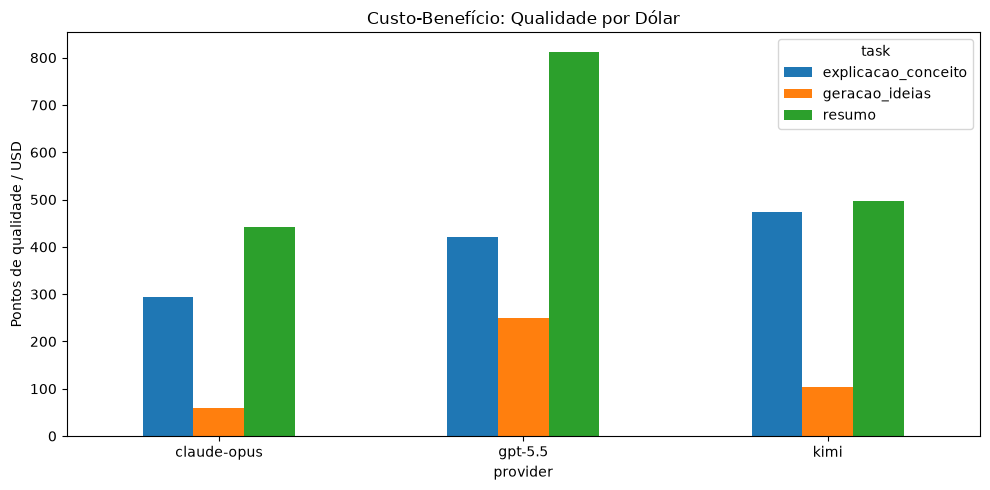

In [14]:
# Gráfico de custo-benefício
df_efficiency = df_all.pivot(index="provider", columns="task", values="efficiency")
df_efficiency.plot.bar(figsize=(10, 5), title="Custo-Benefício: Qualidade por Dólar", rot=0)
plt.ylabel("Pontos de qualidade / USD")
plt.tight_layout()
plt.show()

## 12. Exportação dos resultados

In [15]:
# Métricas (planilha enxuta) + respostas completas em arquivo separado
df_all[METRIC_COLUMNS + ["quality_score", "efficiency"]].to_csv(
    "benchmark_textual_resultados.csv", index=False
)
df_all.to_csv("benchmark_textual_respostas.csv", index=False)
print("Resultados salvos em benchmark_textual_resultados.csv")
print("Respostas completas salvas em benchmark_textual_respostas.csv")

Resultados salvos em benchmark_textual_resultados.csv
Respostas completas salvas em benchmark_textual_respostas.csv


## 13. Conclusão da aula

Com base nos dados coletados, responda:

1. Qual modelo teve o **menor custo** em cada tarefa?
2. Qual modelo teve a **melhor qualidade** de resposta?
3. Qual modelo teve o **melhor custo-benefício**?
4. Em quais cenários o Kimi se mostrou competitivo em relação aos concorrentes?

Use os dados do DataFrame para justificar suas respostas.